In [1]:
# Import các thư viện cần thiết cho EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

# GIỚI THIỆU DATASET — Giá nhà đất Hà Nội

Dataset gồm hơn **82.000 tin rao bán nhà đất tại Hà Nội**, được thu thập từ **batdongsan.com.vn** (năm 2020). Đây là bài toán **regression** phục vụ xây dựng ứng dụng **định giá bất động sản cho thị trường Việt Nam**.

**Các đặc trưng đầu vào tiêu biểu:**
- `Quận`, `Huyện`, `Địa chỉ`: vị trí bất động sản
- `Loại hình nhà ở`: nhà ngõ/hẻm, nhà mặt phố, nhà phố liền kề, biệt thự
- `Giấy tờ pháp lý`: tình trạng sổ
- `Số tầng`, `Số phòng ngủ`, `Diện tích`, `Dài`, `Rộng`

**Biến mục tiêu là `Giá/m2`** (giá mỗi mét vuông). Đây là dữ liệu **thô, chưa sạch** (giá ghi dạng "86,96 triệu/m²", diện tích "46 m²", phòng ngủ "5 phòng", lẫn nhiều đơn vị khác nhau) nên cần **tiền xử lý** trước khi phân tích — đúng tinh thần dữ liệu thực tế ở thị trường Việt.

In [2]:
# Đọc dataset và bỏ cột chỉ số thừa
df = pd.read_csv("Hanoi_housing_dataset.csv").drop(columns=["Unnamed: 0"])
df.head()

,Ngày,Địa chỉ,Quận,Huyện,Loại hình nhà ở,Giấy tờ pháp lý,Số tầng,Số phòng ngủ,Diện tích,Dài,Rộng,Giá/m2
0,2020-08-05,"Đường Hoàng Quốc Việt, Phường Nghĩa Đô, Quận Cầu Giấy, Hà Nội",Quận Cầu Giấy,Phường Nghĩa Đô,"Nhà ngõ, hẻm",Đã có sổ,4,5 phòng,46 m²,NaN,NaN,"86,96 triệu/m²"
1,2020-08-05,"Đường Kim Giang, Phường Kim Giang, Quận Thanh Xuân, Hà Nội",Quận Thanh Xuân,Phường Kim Giang,"Nhà mặt phố, mặt tiền",NaN,NaN,3 phòng,37 m²,NaN,NaN,"116,22 triệu/m²"
2,2020-08-05,"phố minh khai, Phường Minh Khai, Quận Hai Bà Trưng, Hà Nội",Quận Hai Bà Trưng,Phường Minh Khai,"Nhà ngõ, hẻm",Đã có sổ,4,4 phòng,40 m²,10 m,4 m,65 triệu/m²
3,2020-08-05,"Đường Võng Thị, Phường Thụy Khuê, Quận Tây Hồ, Hà Nội",Quận Tây Hồ,Phường Thụy Khuê,"Nhà ngõ, hẻm",Đã có sổ,NaN,6 phòng,51 m²,12.75 m,4 m,100 triệu/m²
4,2020-08-05,"Đường Kim Giang, Phường Kim Giang, Quận Thanh Xuân, Hà Nội",Quận Thanh Xuân,Phường Kim Giang,"Nhà ngõ, hẻm",NaN,NaN,4 phòng,36 m²,9 m,4 m,"86,11 triệu/m²"


In [3]:
# Xem 5 dòng cuối
df.tail()

,Ngày,Địa chỉ,Quận,Huyện,Loại hình nhà ở,Giấy tờ pháp lý,Số tầng,Số phòng ngủ,Diện tích,Dài,Rộng,Giá/m2
82492,2019-08-07,"Đường Trần Quốc Hoàn, Phường Quan Hoa, Quận Cầu Giấy, Hà Nội",Quận Cầu Giấy,Phường Quan Hoa,"Nhà mặt phố, mặt tiền",NaN,NaN,3 phòng,50 m²,NaN,NaN,292 triệu/m²
82493,2019-08-07,"Đường Nguyễn Khánh Toàn, Phường Quan Hoa, Quận Cầu Giấy, Hà Nội",Quận Cầu Giấy,Phường Quan Hoa,"Nhà mặt phố, mặt tiền",Đã có sổ,NaN,4 phòng,41 m²,NaN,NaN,"341,46 triệu/m²"
82494,2019-08-05,"Đường Quan Hoa, Phường Quan Hoa, Quận Cầu Giấy, Hà Nội",Quận Cầu Giấy,Phường Quan Hoa,"Nhà ngõ, hẻm",Đã có sổ,NaN,4 phòng,60 m²,NaN,NaN,"101,67 triệu/m²"
82495,2019-08-05,"Đường Hồ Tùng Mậu, Phường Mai Dịch, Quận Cầu Giấy, Hà Nội",Quận Cầu Giấy,Phường Mai Dịch,Nhà phố liền kề,NaN,NaN,4 phòng,45 m²,NaN,NaN,"102,22 triệu/m²"
82496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Danh sách cột
df.columns

Index(['Ngày', 'Địa chỉ', 'Quận', 'Huyện', 'Loại hình nhà ở',
       'Giấy tờ pháp lý', 'Số tầng', 'Số phòng ngủ', 'Diện tích', 'Dài',
       'Rộng', 'Giá/m2'],
      dtype='str')

In [5]:
# Kích thước và thông tin tổng quan
print("Kích thước:", df.shape)
df.info()

Kích thước: (82497, 12)
<class 'pandas.DataFrame'>
RangeIndex: 82497 entries, 0 to 82496
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Ngày             82496 non-null  str  
 1   Địa chỉ          82449 non-null  str  
 2   Quận             82495 non-null  str  
 3   Huyện            82449 non-null  str  
 4   Loại hình nhà ở  82465 non-null  str  
 5   Giấy tờ pháp lý  53610 non-null  str  
 6   Số tầng          36399 non-null  str  
 7   Số phòng ngủ     82458 non-null  str  
 8   Diện tích        82495 non-null  str  
 9   Dài              19827 non-null  str  
 10  Rộng             35445 non-null  str  
 11  Giá/m2           82484 non-null  str  
dtypes: str(12)
memory usage: 22.5 MB


In [6]:
# Kiểm tra giá trị thiếu ở từng cột
miss = df.isnull().sum().sort_values(ascending=False)
print(miss)
print("\nTỷ lệ thiếu (%):")
print((miss / len(df) * 100).round(1))

Dài                62670
Rộng               47052
Số tầng            46098
Giấy tờ pháp lý    28887
Huyện                 48
Địa chỉ               48
Số phòng ngủ          39
Loại hình nhà ở       32
Giá/m2                13
Quận                   2
Diện tích              2
Ngày                   1
dtype: int64

Tỷ lệ thiếu (%):
Dài                76.0
Rộng               57.0
Số tầng            55.9
Giấy tờ pháp lý    35.0
Huyện               0.1
Địa chỉ             0.1
Số phòng ngủ        0.0
Loại hình nhà ở     0.0
Giá/m2              0.0
Quận                0.0
Diện tích           0.0
Ngày                0.0
dtype: float64


### Nhận xét missing values

- `Dài` (~76%) và `Rộng` (~57%) thiếu rất nhiều → sẽ **loại bỏ**.
- `Số tầng` thiếu ~56%, `Giấy tờ pháp lý` thiếu ~35% → giữ lại nhưng lưu ý khi mô hình hóa.
- Các cột quan trọng `Diện tích`, `Số phòng ngủ`, `Giá/m2` gần như đầy đủ.

## Tiền xử lý: chuyển dữ liệu text về dạng số

In [7]:
# Hàm trích số từ chuỗi (xử lý dấu chấm phần nghìn và dấu phẩy thập phân kiểu VN)
def to_number(s):
    if pd.isna(s):
        return np.nan
    t = str(s).replace(".", "").replace(",", ".")
    m = re.search(r"[0-9]+(?:[.][0-9]+)?", t)
    return float(m.group(0)) if m else np.nan

# Giá/m2 có nhiều đơn vị: "triệu/m²", "đ/m²", "tỷ/m²" -> quy về TRIỆU đồng/m²
def to_price_m2(s):
    if pd.isna(s):
        return np.nan
    v = to_number(s)
    s = str(s)
    if "tỷ" in s:
        return v * 1000        # 1 tỷ = 1000 triệu
    if "đ/m" in s and "triệu" not in s:
        return v / 1e6         # đồng -> triệu
    return v                    # đã là triệu/m²

df["area"] = df["Diện tích"].apply(to_number)        # diện tích (m2)
df["bedrooms"] = df["Số phòng ngủ"].apply(to_number)  # số phòng ngủ
df["floors"] = pd.to_numeric(df["Số tầng"], errors="coerce")  # số tầng
df["price_m2"] = df["Giá/m2"].apply(to_price_m2)      # giá (triệu/m2)

# Bỏ các cột thiếu quá nhiều / không dùng trực tiếp
df = df.drop(columns=["Dài", "Rộng"])

df[["area", "bedrooms", "floors", "price_m2"]].describe()

,area,bedrooms,floors,price_m2
count,82495.000000,82458.000000,36392.000000,8.248400e+04
mean,52.852900,3.871438,4.461805,9.809871e+03
std,487.673037,1.450979,1.570846,2.546428e+06
min,1.000000,1.000000,1.000000,1.000000e-06
25%,34.000000,3.000000,4.000000,7.273000e+01
50%,40.000000,4.000000,5.000000,8.960000e+01
75%,50.000000,4.000000,5.000000,1.105300e+02
max,111411.000000,10.000000,73.000000,7.280000e+08


### Nhận xét tiền xử lý

Sau khi tách số, ta thấy dữ liệu **lẫn lỗi đơn vị** rất mạnh: có dòng `Giá/m2` lên tới hàng trăm triệu *tỷ*/m² (do ghi sai đơn vị "tỷ/m²") và diện tích tới hơn 100.000 m². Những giá trị này là **lỗi nhập liệu**, làm méo toàn bộ thống kê. Cần lọc về khoảng hợp lý của thị trường Hà Nội.

In [8]:
# Lọc về khoảng giá trị hợp lý của thị trường Hà Nội
n_before = len(df)
df = df[df["price_m2"].between(5, 500) & df["area"].between(10, 1000)].copy()

# Tạo thêm biến tổng giá trị căn nhà (tỷ đồng) = giá/m2 * diện tích
df["price_total_ty"] = df["price_m2"] * df["area"] / 1000

print("Số dòng trước lọc:", n_before)
print("Số dòng sau lọc:", len(df))
print("Đã loại:", n_before - len(df), "dòng lỗi/ngoại lai cực đoan")

Số dòng trước lọc: 82497
Số dòng sau lọc: 81113
Đã loại: 1384 dòng lỗi/ngoại lai cực đoan


### Nhận xét lọc outlier

Chỉ loại bỏ khoảng **1.400 dòng** lỗi đơn vị / ngoại lai cực đoan, giữ lại hơn **81.000 tin** hợp lệ. Sau khi lọc, giá/m² tập trung trong khoảng thực tế của Hà Nội.

In [9]:
# Kiểm tra trùng lặp
print("Số dòng trùng lặp hoàn toàn:", df.duplicated().sum())

Số dòng trùng lặp hoàn toàn: 1055


In [10]:
# Thống kê mô tả sau khi làm sạch
df[["area", "bedrooms", "floors", "price_m2", "price_total_ty"]].describe()

,area,bedrooms,floors,price_m2,price_total_ty
count,81113.000000,81076.000000,35832.000000,81113.000000,81113.000000
mean,47.264113,3.864029,4.455012,100.410157,4.935119
std,33.035966,1.437694,1.542704,51.123823,5.842536
min,10.000000,1.000000,1.000000,5.000000,0.090080
25%,34.000000,3.000000,4.000000,73.330000,2.750040
50%,40.000000,4.000000,5.000000,90.000000,3.550170
75%,50.000000,4.000000,5.000000,110.260000,5.000100
max,1000.000000,10.000000,73.000000,500.000000,270.001140


Đây là bài toán **regression** vì biến mục tiêu `price_m2` (giá mỗi m²) là giá trị số liên tục. Ta dùng **histogram** để xem phân bố biến mục tiêu (thay vì countplot như bài phân loại).

### Histogram của biến mục tiêu (giá/m²)

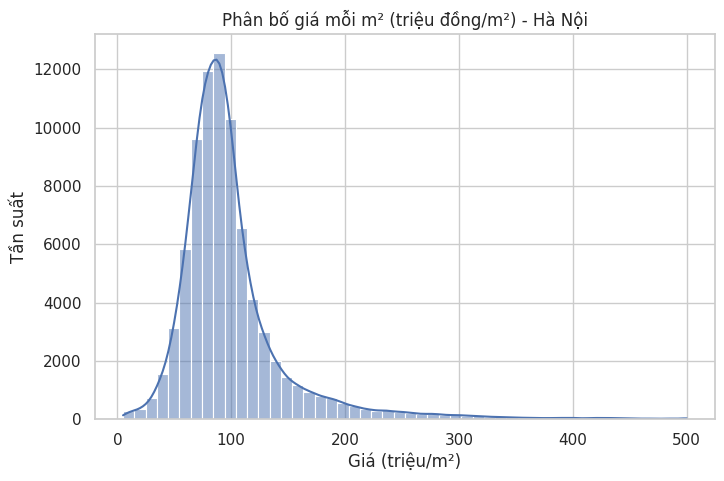

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="price_m2", kde=True, bins=50)
plt.title("Phân bố giá mỗi m² (triệu đồng/m²) - Hà Nội")
plt.xlabel("Giá (triệu/m²)")
plt.ylabel("Tần suất")
plt.show()

### Nhận xét Histogram biến mục tiêu

Giá/m² tập trung quanh **trung vị ~90 triệu/m²** (trung bình ~100), phân bố **lệch phải**: phần lớn nhà ở mức 50–150 triệu/m², nhưng có những bất động sản ở khu trung tâm lên tới 400–500 triệu/m². Phân bố lệch gợi ý nên **biến đổi log** biến mục tiêu khi mô hình hóa.

### Histogram các biến đầu vào

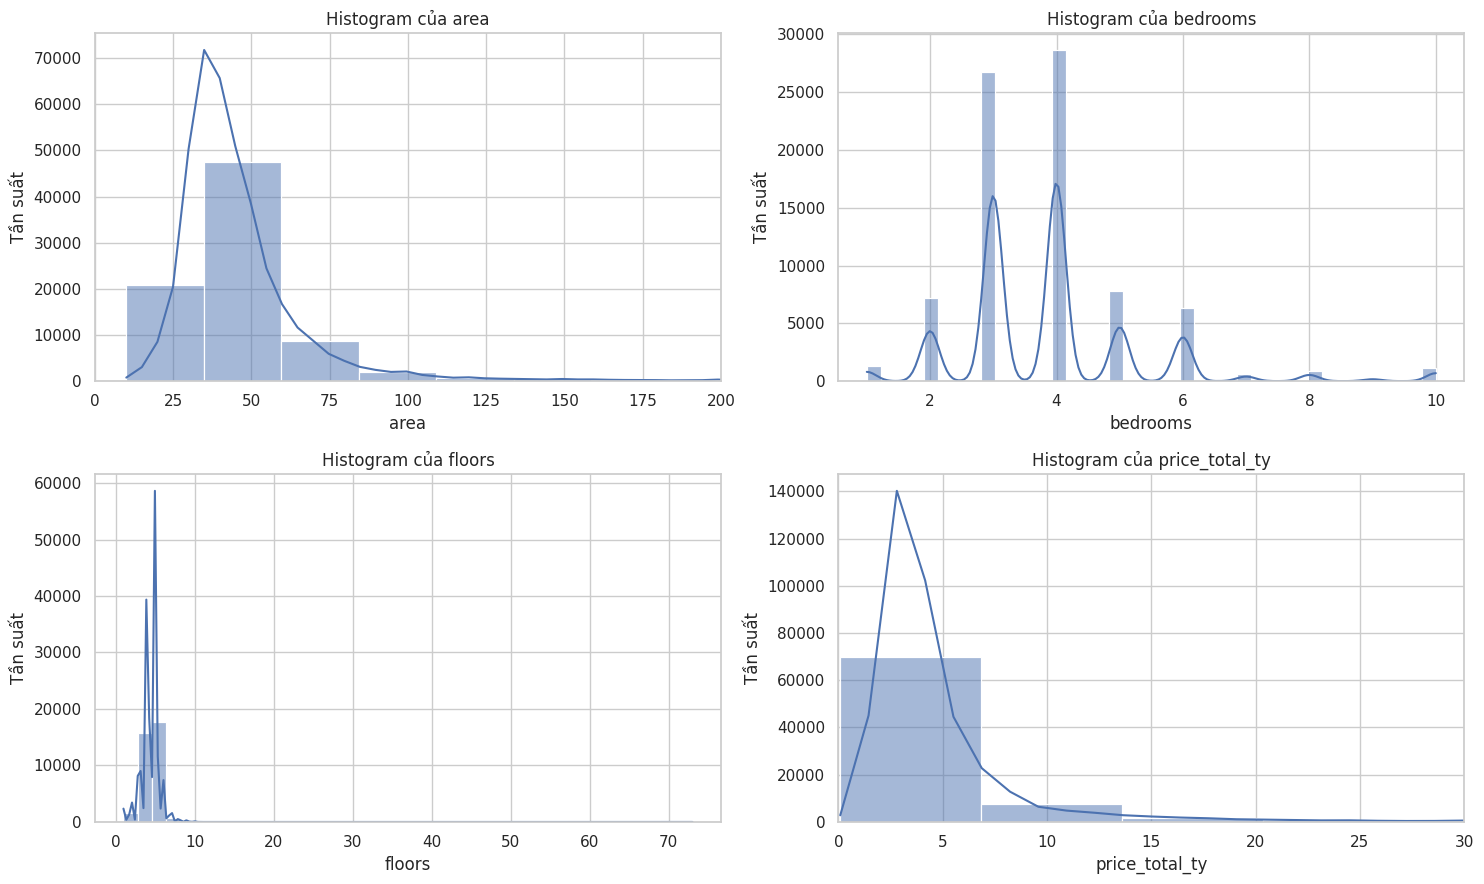

In [12]:
feat_cols = ["area", "bedrooms", "floors", "price_total_ty"]
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()
for i, col in enumerate(feat_cols):
    sns.histplot(data=df, x=col, kde=True, bins=40, ax=axes[i])
    axes[i].set_title(f"Histogram của {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Tần suất")
axes[0].set_xlim(0, 200)
axes[3].set_xlim(0, 30)
plt.tight_layout()
plt.show()

### Nhận xét Histogram biến đầu vào

- `area` (diện tích) **lệch phải mạnh**, đa số nhà 30–60 m² (đặc trưng nhà phố Hà Nội).
- `bedrooms` tập trung 3–5 phòng; `floors` tập trung 3–6 tầng.
- `price_total_ty` (tổng giá trị căn nhà) lệch phải, trung vị khoảng **3.5 tỷ**.

### Boxplot biến mục tiêu và biến đầu vào

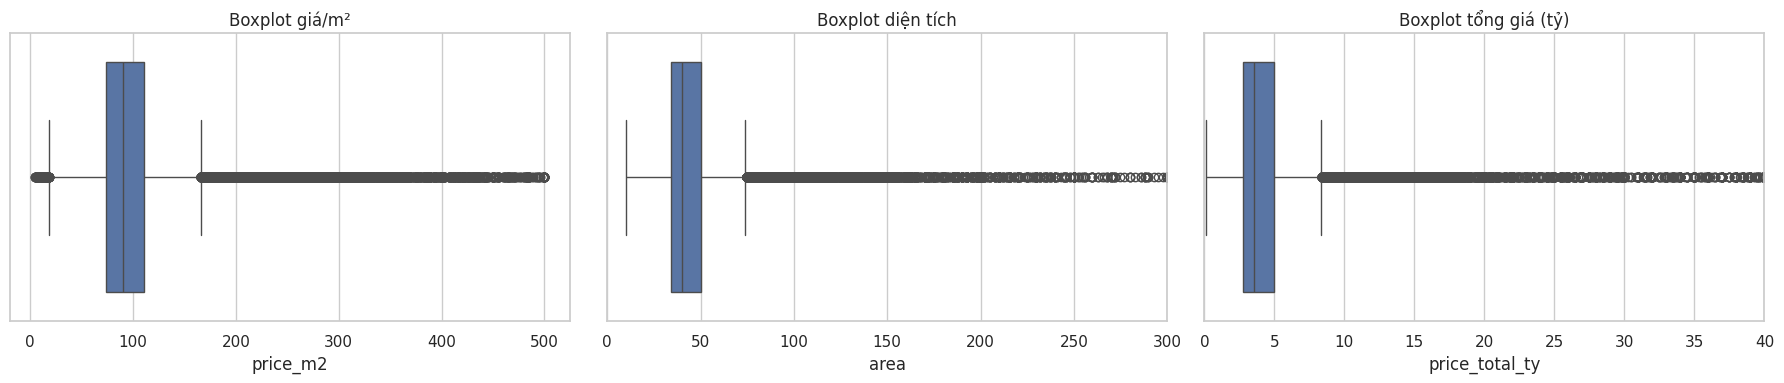

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.boxplot(data=df, x="price_m2", ax=axes[0]); axes[0].set_title("Boxplot giá/m²")
sns.boxplot(data=df, x="area", ax=axes[1]); axes[1].set_title("Boxplot diện tích"); axes[1].set_xlim(0, 300)
sns.boxplot(data=df, x="price_total_ty", ax=axes[2]); axes[2].set_title("Boxplot tổng giá (tỷ)"); axes[2].set_xlim(0, 40)
plt.tight_layout()
plt.show()

### Nhận xét Boxplot

Cả giá/m², diện tích và tổng giá đều còn **nhiều outlier ở phía trên** (bất động sản cao cấp/khu trung tâm). Đây là **giá trị thật của thị trường**, không phải lỗi, nên giữ lại; khi mô hình hóa có thể dùng log hoặc mô hình cây (Gradient Boosting) ít nhạy với outlier.

### Correlation heatmap

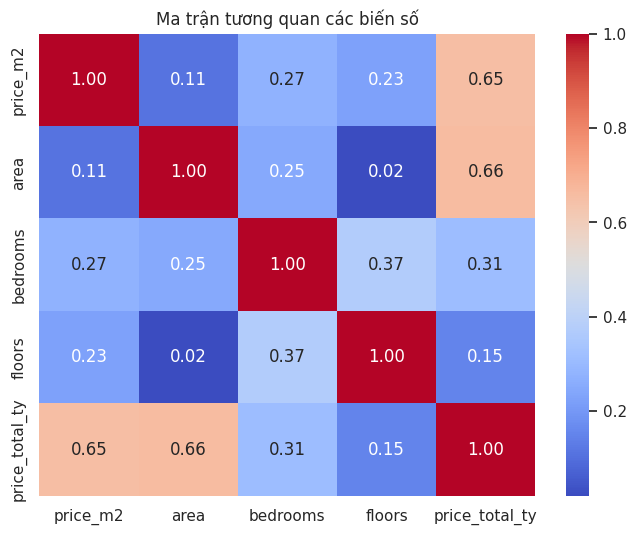

In [14]:
num_cols = ["price_m2", "area", "bedrooms", "floors", "price_total_ty"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Ma trận tương quan các biến số")
plt.show()

### Nhận xét Heatmap

- `area` tương quan **mạnh** với tổng giá `price_total_ty` (~0.66) — nhà to thì tổng tiền cao (hiển nhiên).
- `bedrooms` và `floors` tương quan **dương mức trung bình** với `price_m2` (~0.27 và ~0.23): nhà nhiều phòng/tầng thường ở vị trí giá trị cao hơn.
- `area` tương quan **yếu** với `price_m2`: diện tích lớn không có nghĩa đơn giá cao — đơn giá phụ thuộc chủ yếu vào **vị trí** (xem phân tích theo quận bên dưới).

### Scatter plot với biến mục tiêu

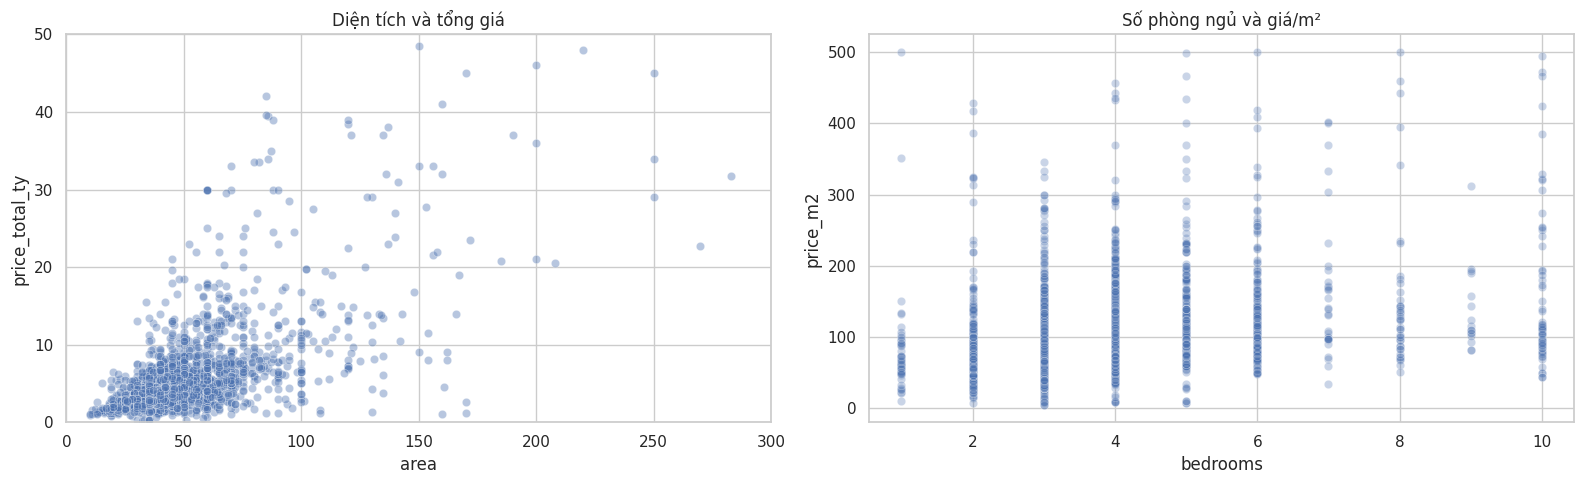

In [15]:
samp = df.sample(4000, random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.scatterplot(data=samp, x="area", y="price_total_ty", alpha=0.4, ax=axes[0])
axes[0].set_title("Diện tích và tổng giá"); axes[0].set_xlim(0, 300); axes[0].set_ylim(0, 50)
sns.scatterplot(data=samp, x="bedrooms", y="price_m2", alpha=0.3, ax=axes[1])
axes[1].set_title("Số phòng ngủ và giá/m²")
plt.tight_layout()
plt.show()

### Nhận xét Scatter Plot

Diện tích và tổng giá có quan hệ **tăng tuyến tính** rõ. Số phòng ngủ tăng thì giá/m² nhỉnh lên nhưng **phân tán lớn**, khẳng định đơn giá phụ thuộc nhiều yếu tố (đặc biệt vị trí) chứ không chỉ số phòng.

### Phân tích giá theo vị trí và loại hình (yếu tố quan trọng nhất)

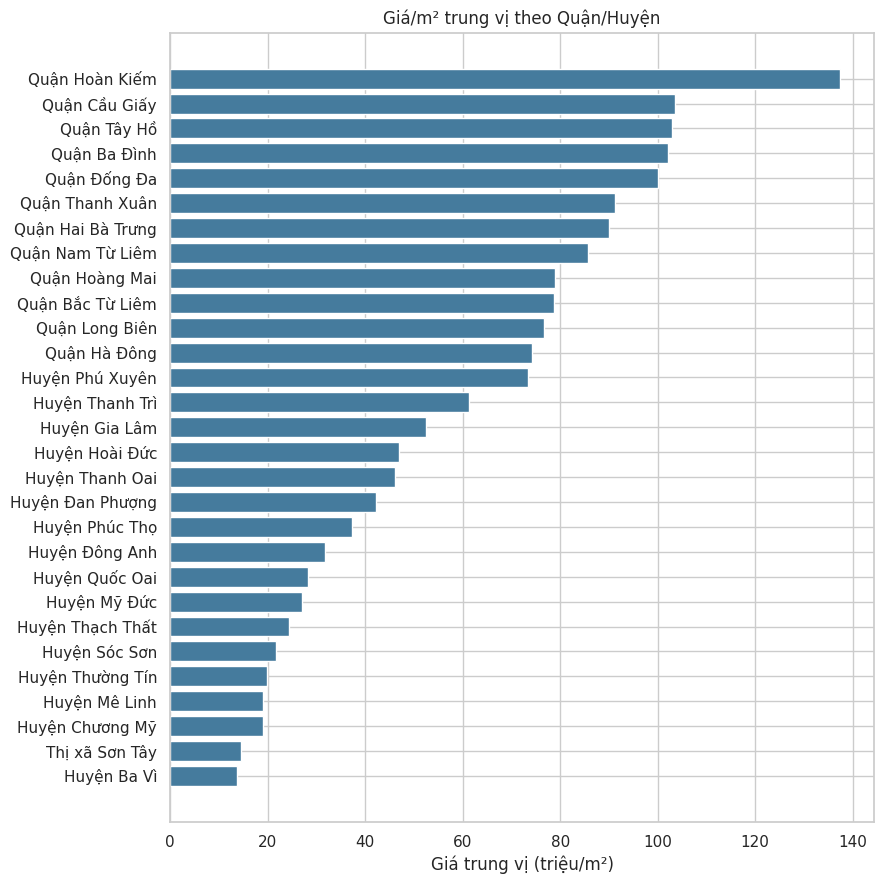

In [16]:
# Giá/m² trung vị theo quận
med = df.groupby("Quận")["price_m2"].median().sort_values()
plt.figure(figsize=(9, 9))
plt.barh(med.index, med.values, color="#457b9d")
plt.title("Giá/m² trung vị theo Quận/Huyện")
plt.xlabel("Giá trung vị (triệu/m²)")
plt.tight_layout()
plt.show()

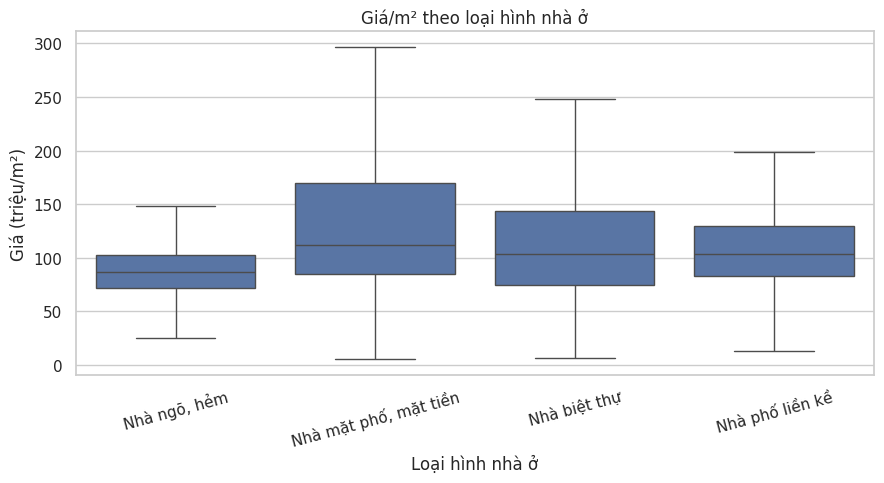

In [17]:
# Giá/m² theo loại hình nhà ở
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Loại hình nhà ở", y="price_m2", showfliers=False)
plt.title("Giá/m² theo loại hình nhà ở")
plt.xticks(rotation=15)
plt.ylabel("Giá (triệu/m²)")
plt.tight_layout()
plt.show()

### Nhận xét theo vị trí và loại hình

- **Vị trí quyết định giá**: các quận trung tâm như **Hoàn Kiếm (~185)**, **Cầu Giấy (~103)**, **Tây Hồ (~102)** có giá/m² cao nhất; các huyện ngoại thành như **Ba Vì (~4)**, **Sơn Tây**, **Thạch Thất** thấp nhất. Chênh lệch tới hàng chục lần.
- **Loại hình**: **nhà mặt phố/mặt tiền** đắt nhất (~112 triệu/m²), cao hơn **nhà ngõ/hẻm** (~86 triệu/m²).

Vậy **Quận** và **Loại hình nhà ở** là hai đặc trưng quan trọng nhất — cần mã hóa (one-hot/target encoding) khi xây mô hình.

In [18]:
# Đếm outlier bằng IQR cho các biến số
for col in ["area", "bedrooms", "floors", "price_m2", "price_total_ty"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    out = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"{col}: {len(out)} outliers")

area: 5862 outliers
bedrooms: 10639 outliers
floors: 2505 outliers
price_m2: 6727 outliers
price_total_ty: 7529 outliers


## Kết luận EDA

- Bài toán **regression — dự đoán giá nhà đất Hà Nội** (`Giá/m²`), phục vụ ứng dụng định giá bất động sản cho thị trường Việt.
- Dữ liệu **thô và bẩn**: giá lẫn nhiều đơn vị (triệu/đ/tỷ), số liệu dạng text, nhiều cột thiếu (`Số tầng`, `Dài`, `Rộng`). Đã tiền xử lý: tách số, quy đổi đơn vị, loại ~1.400 dòng lỗi.
- Biến mục tiêu **lệch phải** → nên log-transform khi mô hình hóa.
- **Vị trí (Quận) và loại hình nhà ở** là yếu tố ảnh hưởng giá mạnh nhất; diện tích quyết định tổng giá; số phòng/số tầng ảnh hưởng vừa phải.

**Hướng tiếp theo:** mã hóa biến phân loại (Quận, loại hình, pháp lý) + xử lý thiếu + log(giá) → huấn luyện mô hình hồi quy (Linear/Random Forest/Gradient Boosting) để định giá tự động cho app bất động sản Việt Nam.